# Quantum EPI GAN — Class-Wise Augmentation for HAM10000

This notebook implements a **Quantum EPI GAN** pipeline to address class imbalance in the
HAM10000 skin lesion dataset (7 classes, imbalance ratio ≈ 58, `NV` is the majority class).

**Pipeline overview**

| Stage | Name | Purpose |
|---|---|---|
| 1 | **Q-DCGAN** (coarse generator) | Hybrid quantum-classical DCGAN, trained class-wise, generates raw synthetic images for each minority class |
| 2 | **Q-Pix2Pix** (refinement) | U-Net (with a quantum bottleneck) + PatchGAN, refines/denoises coarse synthetic images using paired (coarse, real) training |
| 3 | **Reinhard color transfer** | Matches color/texture statistics of refined synthetic images to real images of the same class |

Final synthetic counts are computed so that every class reaches `max_count` (the size of the
majority class), and a consolidated one-hot label CSV is produced at the end.

> **Hardware note:** every model and tensor in this notebook is moved onto `device` (CUDA when
> available) and the classical convolutional stacks — which make up the overwhelming majority of
> the compute — run fully on GPU. The variational quantum circuits (PennyLane `default.qubit`)
> are simulated and remain CPU-bound regardless of `device`; this is a PennyLane/quantum-simulator
> limitation, not a bug in this code. Mixed precision (AMP) is wired up but **disabled by default**
> (`USE_AMP = False`) because naive fp16 can destabilize GAN training and is explicitly forced to
> fp32 around the quantum sub-layers in any case — flip it on if you want to experiment.


## 1. Imports & Setup

In [1]:
import os
import glob
import time
import json
import random
import shutil
import warnings
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import cv2
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LinearLR
import torchvision.transforms as T
from torchvision.utils import make_grid
from tqdm import tqdm

import pennylane as qml



warnings.filterwarnings("ignore")


In [2]:
# ----------------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----------------------------------------------------------------------------
# Device configuration — use CUDA as aggressively as possible.
# Every model / tensor / batch created below is explicitly moved to `device`.
# ----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True   # auto-tune conv kernels for our fixed 64x64 input size
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    print("  No GPU detected — training will run on CPU and will be slow. "
          "Consider running this notebook on a CUDA-enabled machine.")

# Mixed precision toggle. Kept OFF by default for GAN training stability;
# quantum sub-layers are force-cast to fp32 regardless of this flag (see Section 3).
USE_AMP = False

# ----------------------------------------------------------------------------
# Project paths
# ----------------------------------------------------------------------------
PROJECT_ROOT = Path().cwd()
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed_images"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
IMG_SIZE = 64


Using device: cuda
  GPU: NVIDIA GeForce RTX 2050


## 2. Dataset Discovery & Preprocessing

Dataset paths are fixed to the known project layout:
```
skin cancer/
├── dataset/
│   ├── GroundTruth.csv
│   ├── images/
│   └── masks/
└── checkpoints/
```
Lesion masks (when present) are used to crop tightly around the lesion before resizing, instead of an arbitrary center-crop.


In [3]:
# ----------------------------------------------------------------------------
# Fixed dataset paths — no search needed, structure is known:
#   skin cancer/dataset/GroundTruth.csv
#   skin cancer/dataset/images/
#   skin cancer/dataset/masks/
# ----------------------------------------------------------------------------
DATASET_ROOT = PROJECT_ROOT / "dataset"
METADATA_CSV = DATASET_ROOT / "GroundTruth.csv"
IMAGE_DIRS = [DATASET_ROOT / "images"]
MASKS_DIR = DATASET_ROOT / "masks"

CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR = PROJECT_ROOT.parent / "results" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)



logger = logging.getLogger("pix2pix")
logger.setLevel(logging.INFO)
logger.propagate = False  # avoid duplicate lines if root logger also has handlers

if not logger.handlers:  # avoid adding duplicate handlers if this cell re-runs
    file_handler = logging.FileHandler(LOG_DIR / "training.log", mode="a", encoding="utf-8")
    file_handler.setFormatter(logging.Formatter("%(asctime)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S"))
    logger.addHandler(file_handler)

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(stream_handler)


DATASET_FOUND = METADATA_CSV.exists() and IMAGE_DIRS[0].is_dir()

if DATASET_FOUND:
    print(f"Dataset root: {DATASET_ROOT}")
    print(f"Metadata CSV: {METADATA_CSV}")
    print(f"Images dir:   {IMAGE_DIRS[0]}")
    print(f"Masks dir:    {MASKS_DIR} ({'found' if MASKS_DIR.is_dir() else 'NOT FOUND'})")
else:
    print(f"Dataset not found. Expected:\n  {METADATA_CSV}\n  {IMAGE_DIRS[0]}")


Dataset root: c:\Users\shara\Desktop\paper_learning\skin cancer\dataset
Metadata CSV: c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\GroundTruth.csv
Images dir:   c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\images
Masks dir:    c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\masks (found)


In [4]:
# ----------------------------------------------------------------------------
# Load metadata and build a filename -> filepath lookup across all image dirs
# ----------------------------------------------------------------------------
if DATASET_FOUND:
    metadata = pd.read_csv(METADATA_CSV)

    # HAM10000 metadata commonly uses 'image_id' and 'dx' (diagnosis) columns;
    # GroundTruth.csv (ISIC challenge format) uses one-hot columns per class instead.
    # Normalize both formats into: image_id, dx
    if "dx" in metadata.columns:
        metadata = metadata.rename(columns={"image_id": "image_id", "dx": "dx"})
        metadata = metadata[["image_id", "dx"]].copy()
        metadata["dx"] = metadata["dx"].str.upper()
    else:
        # one-hot ISIC GroundTruth.csv format: image, MEL, NV, BCC, AKIEC, BKL, DF, VASC
        id_col = metadata.columns[0]
        onehot_cols = [c for c in CLASS_NAMES if c in metadata.columns]
        metadata["dx"] = metadata[onehot_cols].idxmax(axis=1)
        metadata = metadata.rename(columns={id_col: "image_id"})
        metadata = metadata[["image_id", "dx"]].copy()

    # Build filename -> full path lookup across all discovered image directories
    filename_to_path = {}
    for img_dir in IMAGE_DIRS:
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            for p in img_dir.glob(ext):
                filename_to_path[p.stem] = p

    metadata["filepath"] = metadata["image_id"].map(filename_to_path)
    missing = metadata["filepath"].isna().sum()
    if missing:
        print(f"Warning: {missing} entries in metadata have no matching image file and will be dropped.")
    metadata = metadata.dropna(subset=["filepath"]).reset_index(drop=True)

    print(metadata["dx"].value_counts())
else:
    metadata = pd.DataFrame(columns=["image_id", "dx", "filepath"])


dx
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64


In [5]:
# ----------------------------------------------------------------------------
# Crop (using lesion mask when available) / resize all images to 64x64 and organize
# into class-wise subdirectories:
#   skin cancer/dataset/processed_images/{CLASS}/real/{image_id}.jpg
# ----------------------------------------------------------------------------
def crop_to_mask_and_resize(img: np.ndarray, mask: np.ndarray = None, size: int = IMG_SIZE) -> np.ndarray:
    """
    If a lesion mask is given, crop to its bounding box (with a small margin) before resizing —
    this centers the lesion instead of an arbitrary center-crop. Falls back to center-crop
    when no mask is available or the mask is empty.
    """
    h, w = img.shape[:2]
    if mask is not None:
        ys, xs = np.where(mask > 0)
        if len(ys) > 0:
            margin = int(0.1 * max(h, w))
            top = max(0, ys.min() - margin)
            bottom = min(h, ys.max() + margin)
            left = max(0, xs.min() - margin)
            right = min(w, xs.max() + margin)
            cropped = img[top:bottom, left:right]
            return cv2.resize(cropped, (size, size), interpolation=cv2.INTER_AREA)

    crop_dim = min(h, w)
    top, left = (h - crop_dim) // 2, (w - crop_dim) // 2
    cropped = img[top:top + crop_dim, left:left + crop_dim]
    return cv2.resize(cropped, (size, size), interpolation=cv2.INTER_AREA)


def find_mask_for(image_id: str, masks_dir: Path) -> np.ndarray:
    """HAM10000/ISIC masks are typically named '{image_id}_segmentation.png'."""
    for pattern in (f"{image_id}_segmentation.png", f"{image_id}.png"):
        p = masks_dir / pattern
        if p.exists():
            return cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    return None


def preprocess_dataset(metadata: pd.DataFrame, processed_dir: Path, img_size: int = IMG_SIZE,
                        masks_dir: Path = None):
    class_counts = {}
    for cls in CLASS_NAMES:
        cls_dir = processed_dir / cls / "real"
        cls_dir.mkdir(parents=True, exist_ok=True)

        rows = metadata[metadata["dx"] == cls]
        count = 0
        for _, row in rows.iterrows():
            out_path = cls_dir / f"{row['image_id']}.jpg"
            if out_path.exists():
                count += 1
                continue
            img_bgr = cv2.imread(str(row["filepath"]))
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            mask = find_mask_for(row["image_id"], masks_dir) if masks_dir and masks_dir.is_dir() else None
            processed = crop_to_mask_and_resize(img_rgb, mask, img_size)

            cv2.imwrite(str(out_path), cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))
            count += 1
        class_counts[cls] = count
    return class_counts


if DATASET_FOUND:
    class_counts = preprocess_dataset(metadata, PROCESSED_DIR, IMG_SIZE, masks_dir=MASKS_DIR)
    print("Real (preprocessed) image counts per class:")
    for cls, n in class_counts.items():
        print(f"  {cls}: {n}")

    max_count = max(class_counts.values())
    majority_class = max(class_counts, key=class_counts.get)
    minority_classes = [c for c in CLASS_NAMES if c != majority_class]
    needed_counts = {c: max_count - class_counts[c] for c in minority_classes}

    print(f"\nMajority class: {majority_class} ({max_count} images)")
    print("Images needed per minority class to reach max_count:")
    for c, n in needed_counts.items():
        print(f"  {c}: {n}")
else:
    class_counts, max_count, majority_class, minority_classes, needed_counts = {}, 0, None, [], {}


Real (preprocessed) image counts per class:
  MEL: 1113
  NV: 6705
  BCC: 514
  AKIEC: 327
  BKL: 1099
  DF: 115
  VASC: 142

Majority class: NV (6705 images)
Images needed per minority class to reach max_count:
  MEL: 5592
  BCC: 6191
  AKIEC: 6378
  BKL: 5606
  DF: 6590
  VASC: 6563


In [6]:
class ClassImageDataset(Dataset):
    """Loads all real images for a single class from `processed_images/{cls}/real/`."""

    def __init__(self, class_name: str, processed_dir: Path = PROCESSED_DIR, img_size: int = IMG_SIZE):
        self.class_name = class_name
        self.dir = processed_dir / class_name / "real"
        self.paths = sorted(self.dir.glob("*.jpg"))
        self.transform = T.Compose([
            T.ToTensor(),                          # [0,1], shape (3, H, W)
            T.Normalize([0.5] * 3, [0.5] * 3),     # -> [-1, 1] to match generator tanh output
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


def make_loader(class_name, batch_size=8, num_workers=0):
    ds = ClassImageDataset(class_name)
    if len(ds) == 0:
        return None
    return DataLoader(
        ds, batch_size=min(batch_size, len(ds)), shuffle=True,
        num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=True,
    )


## 3. Variational Quantum Circuit (VQC) & Hybrid Quantum Layer

A reusable hybrid quantum-classical layer used in both:
- the **Q-DCGAN generator** (Stage 1), mapping the 100-dim noise vector through 8 qubits, and
- the **Q-Pix2Pix U-Net bottleneck** (Stage 2), performing quantum representation learning on the
  flattened 4×4×512 latent.

**Circuit:** angle-embed classical features into rotation angles, apply `StronglyEntanglingLayers`
for the variational part, and measure `PauliZ` expectation values on every qubit.

Quantum simulation (PennyLane `default.qubit`) is CPU-bound regardless of `device`; we therefore
explicitly force fp32 and run the quantum sub-call outside of any active autocast context so that
mixing it into a CUDA/AMP-trained network never silently breaks or downcasts its inputs.


In [7]:
N_QUBITS = 8
N_LAYERS = 2

# Use lightning.qubit (fast C++ backend) when available; fall back to default.qubit.
# lightning.qubit uses adjoint differentiation which is much faster than backprop simulation.
try:
    import pennylane_lightning  # pip install pennylane-lightning
    qdevice = qml.device("lightning.qubit", wires=N_QUBITS)
    DIFF_METHOD = "adjoint"
    print("Using lightning.qubit (fast C++ backend)")
except ImportError:
    qdevice = qml.device("default.qubit", wires=N_QUBITS)
    DIFF_METHOD = "backprop"
    print("Falling back to default.qubit")


@qml.qnode(qdevice, interface="torch", diff_method=DIFF_METHOD)
def vqc_circuit(inputs, weights):
    """
    inputs:  (N_QUBITS,) tensor scaled to [-pi, pi]
    weights: (N_LAYERS, N_QUBITS, 3) variational parameters
    """
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="X")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


VQC_WEIGHT_SHAPES = {"weights": (N_LAYERS, N_QUBITS, 3)}


class HybridQuantumLayer(nn.Module):
    """
    Linear(in_features -> n_qubits) -> tanh*pi scaling -> VQC -> Linear(n_qubits -> out_features)

    The VQC sub-call is always executed in fp32 and outside of any active autocast context,
    since PennyLane's TorchLayer does not support half precision. This makes the layer safe to
    embed inside an AMP-wrapped model on CUDA without silently corrupting gradients.
    """

    def __init__(self, in_features: int, out_features: int, n_qubits: int = N_QUBITS, n_layers: int = N_LAYERS):
        super().__init__()
        self.n_qubits = n_qubits
        self.pre = nn.Linear(in_features, n_qubits)
        self.qlayer = qml.qnn.TorchLayer(vqc_circuit, VQC_WEIGHT_SHAPES)
        self.post = nn.Linear(n_qubits, out_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pre(x)
        x = torch.tanh(x) * torch.pi
        original_device = x.device
        with autocast(device_type="cpu", enabled=False):
            x = self.qlayer(x.float().cpu())
        x = x.to(device=original_device)
        x = self.post(x)
        return x


Using lightning.qubit (fast C++ backend)


In [8]:
# Quick sanity check of the hybrid layer (shape + gradient flow), run on `device`.
_test_layer = HybridQuantumLayer(100, 2048).to(device)
_test_input = torch.randn(4, 100, device=device)
_test_out = _test_layer(_test_input)
print("HybridQuantumLayer test output shape:", _test_out.shape)
_test_out.sum().backward()
print("Gradient reaches quantum weights:", _test_layer.qlayer.weights.grad is not None)
del _test_layer, _test_input, _test_out


HybridQuantumLayer test output shape: torch.Size([4, 2048])
Gradient reaches quantum weights: True


## 4. Stage 1 — Q-DCGAN (Coarse Generator)

A DCGAN whose generator maps a 100-dim noise vector through the `HybridQuantumLayer` (100 → 8
qubits → 2048 features), reshaped to `(128, 4, 4)` and upsampled via transposed convolutions to
`3×64×64`. The discriminator is a standard strided-convolution classifier.

Trained **class-wise**: one fresh Generator/Discriminator pair per minority class, using only the
real images of that class. After training, we sample enough noise vectors to bring each minority
class up to `max_count` synthetic images, saved to `processed_images/{class}/augmented/`.


In [9]:
class QDCGANGenerator(nn.Module):
    def __init__(self, nz: int = 100):
        super().__init__()
        self.nz = nz
        self.quantum = HybridQuantumLayer(nz, 128 * 4 * 4)
        self.net = nn.Sequential(
            # 128x4x4 -> 128x8x8
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            # 128x8x8 -> 64x16x16
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            # 64x16x16 -> 32x32x32
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            # 32x32x32 -> 3x64x64
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 3, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x is expected to be pre-computed quantum features (output of HybridQuantumLayer),
        # not raw noise. The quantum sub-layer is intentionally not called here — it was
        # pre-applied once during quantum_cache construction and is frozen (not trained).
        x = x.view(-1, 128, 4, 4)
        return self.net(x)


class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.1),    # 32x32x32
            nn.Conv2d(32, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.1),   # 64x16x16
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.1),  # 128x8x8
            nn.Conv2d(128, 1, 4, 2, 1),                                                      # 1x4x4
        )
        self.classifier = nn.Linear(4 * 4, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.net(x)
        x = x.flatten(1)
        return self.classifier(x)


# ----------------------------------------------------------------------------
# Quantum feature pre-computation — run the quantum layer ONCE per class
# before training begins, caching outputs so the hot training loop stays fast.
# ----------------------------------------------------------------------------
@torch.no_grad()
def precompute_quantum_noise(n_samples: int, nz: int = 100, batch_size: int = 32):
    """
    Pre-run the quantum projection for all noise vectors we will ever need.
    Returns a tensor of shape (n_samples, 128*4*4) on CPU.
    These cached features replace live quantum calls inside the training loop,
    moving the quantum bottleneck out of the hot path completely.
    """
    print(f"Pre-computing {n_samples} quantum noise features (runs ONCE, then cached)...")
    qlayer = HybridQuantumLayer(nz, 128 * 4 * 4, n_qubits=N_QUBITS, n_layers=N_LAYERS)
    qlayer.eval()
    all_features = []
    for i in range(0, n_samples, batch_size):
        cur = min(batch_size, n_samples - i)
        z = torch.randn(cur, nz)
        feats = qlayer(z)          # (cur, 128*4*4) — runs on CPU, intentionally
        all_features.append(feats.cpu())
        if i % (batch_size * 10) == 0:
            print(f"  {min(i + batch_size, n_samples)}/{n_samples} quantum features computed...")
    print("Pre-computation complete.")
    return torch.cat(all_features, dim=0)   # (n_samples, 128*4*4)


In [10]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


def train_qdcgan_for_class(
        class_name: str,
        n_epochs: int = 50,
        batch_size: int = 8,
        nz: int = 100,
        lr: float = 2e-4,
        log_every: int = 10):

    print("" + "=" * 80)
    print(f"Starting Q-DCGAN training for class: {class_name}")
    print(f"Device       : {device}")
    print(f"Epochs       : {n_epochs}")
    print(f"Batch size   : {batch_size}")
    print(f"Latent dim   : {nz}")
    print(f"Learning rate: {lr}")
    print("=" * 80)

    loader = make_loader(class_name, batch_size=batch_size)

    if loader is None:
        print(f"[{class_name}] No real images found — skipping Q-DCGAN training.")
        return None

    print(f"[{class_name}] Number of batches: {len(loader)}")

    # ------------------------------------------------------------------
    # Pre-compute quantum features ONCE before training starts.
    # We need 2 batches per training step (one for D, one for G),
    # across all epochs. Add 20% headroom for safety.
    # ------------------------------------------------------------------
    total_steps = n_epochs * len(loader)
    n_quantum_samples = int(total_steps * batch_size * 2 * 1.2)
    quantum_cache = precompute_quantum_noise(n_quantum_samples, nz=nz, batch_size=64)
    cache_idx = 0   # rolling pointer into quantum_cache

    gen = QDCGANGenerator().to(device)
    disc = DCGANDiscriminator().to(device)
    
    with torch.no_grad():
        _z_check = torch.randn(8, nz, device=device)
        _q_out = gen.quantum(_z_check)
        print(f"[{class_name}] Quantum layer output std (across batch): {_q_out.std().item():.6f}")
        print(f"[{class_name}] Quantum layer output std (per-feature, avg): {_q_out.std(dim=0).mean().item():.6f}")

    gen.net.apply(weights_init)
    disc.net.apply(weights_init)

    print(f"[{class_name}] Generator initialized.")
    print(f"[{class_name}] Discriminator initialized.")

    opt_g = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()

    scaler_g = GradScaler(enabled=USE_AMP)
    scaler_d = GradScaler(enabled=USE_AMP)

    gen.train()
    disc.train()

    training_start = time.time()

    for epoch in range(n_epochs):

        epoch_start = time.time()
        running_g = 0.0
        running_d = 0.0

        pbar = tqdm(
            loader,
            desc=f"[{class_name}] Epoch {epoch+1}/{n_epochs}",
            leave=True
        )

        for real in pbar:

            real = real.to(device, non_blocking=True)
            bsz = real.size(0)

            real_labels = torch.ones(bsz, 1, device=device)
            fake_labels = torch.zeros(bsz, 1, device=device)

            # --------------------
            # Train Discriminator
            # --------------------
            opt_d.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=USE_AMP):
                # Pull pre-computed quantum features from cache (no quantum call here)
                q_feat_d = quantum_cache[cache_idx:cache_idx + bsz].to(device)
                cache_idx = (cache_idx + bsz) % len(quantum_cache)
                fake = gen(q_feat_d).detach()

                d_real = disc(real)
                d_fake = disc(fake)
                loss_d = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

            scaler_d.scale(loss_d).backward()
            scaler_d.step(opt_d)
            scaler_d.update()

            # --------------------
            # Train Generator
            # --------------------
            opt_g.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=USE_AMP):
                # Pull next batch of cached features for G update
                q_feat_g = quantum_cache[cache_idx:cache_idx + bsz].to(device)
                cache_idx = (cache_idx + bsz) % len(quantum_cache)
                fake = gen(q_feat_g)

                d_fake_for_g = disc(fake)
                loss_g = criterion(d_fake_for_g, real_labels)

            scaler_g.scale(loss_g).backward()
            scaler_g.step(opt_g)
            scaler_g.update()

            running_d += loss_d.item()
            running_g += loss_g.item()
            pbar.set_postfix(
                D_loss=f"{running_d/(pbar.n+1):.4f}",
                G_loss=f"{running_g/(pbar.n+1):.4f}"
            )

        epoch_time = time.time() - epoch_start

        if (epoch + 1) % log_every == 0 or epoch == n_epochs - 1:
            avg_d = running_d / len(loader)
            avg_g = running_g / len(loader)
            print(
                f"[{class_name}] "
                f"Epoch {epoch+1:03d}/{n_epochs} | "
                f"D_loss={avg_d:.4f} | "
                f"G_loss={avg_g:.4f} | "
                f"Time={epoch_time:.2f}s"
            )

    total_time = time.time() - training_start

    print("" + "=" * 80)
    print(f"[{class_name}] Training completed.")
    print(f"Total training time : {total_time/60:.2f} min")
    print("=" * 80)

    ckpt_path = CHECKPOINTS_DIR / f"qdcgan_{class_name}.pt"
    torch.save(
        {
            "generator": gen.state_dict(),
            "discriminator": disc.state_dict(),
            "epoch": n_epochs,
        },
        ckpt_path
    )
    print(f"[{class_name}] Saved checkpoint → {ckpt_path}")

    gen.eval()
    return gen


In [11]:
def load_qdcgan_checkpoint(class_name: str, nz: int = 100):
    """Loads a previously saved Q-DCGAN generator for , or returns None."""
    ckpt_path = CHECKPOINTS_DIR / f"qdcgan_{class_name}.pt"
    if not ckpt_path.exists():
        return None
    ckpt = torch.load(ckpt_path, map_location=device)
    gen = QDCGANGenerator().to(device)   # no nz — quantum is pre-computed externally
    gen.load_state_dict(ckpt["generator"])
    gen.eval()
    print(f"Loaded {class_name} generator from {ckpt_path} (epoch {ckpt['epoch']})")
    return gen


In [12]:
@torch.no_grad()
def generate_and_save(gen: nn.Module, class_name: str, n_images: int,
                       out_subdir: str = "augmented", nz: int = 100, batch_size: int = 32):
    """
    Samples quantum-projected noise, runs it through , and saves the resulting
    images as JPEGs. Uses precompute_quantum_noise() so the quantum circuit runs
    once per call rather than once per batch.
    """
    if n_images <= 0:
        print(f"[{class_name}] No images needed for '{out_subdir}' — already at max_count.")
        return

    out_dir = PROCESSED_DIR / class_name / out_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    # Pre-compute all quantum features needed for this generation run at once
    print(f"[{class_name}] Pre-computing quantum features for {n_images} images...")
    all_q_feats = precompute_quantum_noise(n_images, nz=nz, batch_size=64)

    gen.eval()
    saved = 0
    while saved < n_images:
        cur_batch = min(batch_size, n_images - saved)
        q_feats = all_q_feats[saved:saved + cur_batch].to(device)
        imgs = gen(q_feats).cpu()       # (-1, 1) range, shape (B, 3, 64, 64)
        imgs = ((imgs + 1) / 2).clamp(0, 1)   # -> [0, 1]
        for i in range(cur_batch):
            arr = (imgs[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            Image.fromarray(arr).save(out_dir / f"aug_{saved + i}.jpg")
        saved += cur_batch
    print(f"[{class_name}] Saved {saved} images to {out_dir}")


In [13]:
# ----------------------------------------------------------------------------
# Execute Stage 1: train class-wise (or load from checkpoint) and generate enough
# coarse synthetic images to bring every minority class up to max_count.
# ----------------------------------------------------------------------------
QDCGAN_EPOCHS = 500       # increase for real training runs; kept small here as a sane default
FORCE_RETRAIN = False    # set True to retrain even if a checkpoint already exists

trained_generators = {}

if DATASET_FOUND:
    for cls in minority_classes:
        n_needed = needed_counts.get(cls, 0)
        if n_needed <= 0:
            continue

        gen = None if FORCE_RETRAIN else load_qdcgan_checkpoint(cls)
        if gen is None:
            print(f"\n=== Training Q-DCGAN for class: {cls} (need {n_needed} synthetic images) ===")
            gen = train_qdcgan_for_class(cls, n_epochs=QDCGAN_EPOCHS , batch_size=8)

        if gen is not None:
            trained_generators[cls] = gen
            generate_and_save(gen, cls, n_needed, out_subdir="augmented")
        if device.type == "cuda":
            torch.cuda.empty_cache()
else:
    print("Dataset not found — skipping Stage 1 training. Re-run Section 2 once the dataset is available.")


Loaded MEL generator from c:\Users\shara\Desktop\paper_learning\skin cancer\checkpoints\qdcgan_MEL.pt (epoch 500)
[MEL] Pre-computing quantum features for 5592 images...
Pre-computing 5592 quantum noise features (runs ONCE, then cached)...
  64/5592 quantum features computed...
  704/5592 quantum features computed...
  1344/5592 quantum features computed...
  1984/5592 quantum features computed...
  2624/5592 quantum features computed...
  3264/5592 quantum features computed...
  3904/5592 quantum features computed...
  4544/5592 quantum features computed...
  5184/5592 quantum features computed...
Pre-computation complete.
[MEL] Saved 5592 images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\MEL\augmented
Loaded BCC generator from c:\Users\shara\Desktop\paper_learning\skin cancer\checkpoints\qdcgan_BCC.pt (epoch 500)
[BCC] Pre-computing quantum features for 6191 images...
Pre-computing 6191 quantum noise features (runs ONCE, then cached)...
  64/6191 qu

In [14]:
class UNetGenerator(nn.Module):
    """U-Net with a quantum bottleneck for Pix2Pix-style refinement, 64x64 RGB in/out."""

    def __init__(self):
        super().__init__()
        self.down1 = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True)
        )  # -> 64x32x32
        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True)
        )  # -> 128x16x16
        self.down3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True)
        )  # -> 256x8x8
        self.down4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True)
        )  # -> 512x4x4

        self.bottleneck_classical = nn.Sequential(
            nn.Linear(8192, 8192), nn.ReLU(inplace=True)
        )
        self.bottleneck_quantum = HybridQuantumLayer(8192, 8192)

        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2 , mode='bilinear' , align_corners=False),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True)
        )  # -> 256x8x8, concat with down3(256) -> 512x8x8
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2 , mode='bilinear' , align_corners=False),
            nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )  # -> 128x16x16, concat with down2(128) -> 256x16x16
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2 , mode='bilinear' , align_corners=False),
            nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )  # -> 64x32x32, concat with down1(64) -> 128x32x32
        self.up4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )  # -> 64x64x64
        self.output = nn.Sequential(
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        d1 = self.down1(x)   # (B, 64,  32, 32)
        d2 = self.down2(d1)  # (B, 128, 16, 16)
        d3 = self.down3(d2)  # (B, 256,  8,  8)
        d4 = self.down4(d3)  # (B, 512,  4,  4)

        b = d4.flatten(1)
        b = self.bottleneck_classical(b) + 0.1 * self.bottleneck_quantum(b)
        b = b.view(-1, 512, 4, 4)

        u1 = self.up1(b)
        u1 = F.interpolate(u1, size=d3.shape[2:])   # force match d3 spatial size
        u1 = torch.cat([u1, d3], dim=1)             # (B, 512, 8, 8)

        u2 = self.up2(u1)
        u2 = F.interpolate(u2, size=d2.shape[2:])   # force match d2 spatial size
        u2 = torch.cat([u2, d2], dim=1)             # (B, 256, 16, 16)

        u3 = self.up3(u2)
        u3 = F.interpolate(u3, size=d1.shape[2:])   # force match d1 spatial size
        u3 = torch.cat([u3, d1], dim=1)             # (B, 128, 32, 32)

        u4 = self.up4(u3)
        u4 = F.interpolate(u4, size=x.shape[2:])    # force match input spatial size
        return self.output(u4)


class PatchGANDiscriminator(nn.Module):
    """Classifies 8x8 patches of the concatenated (input, target) image pair."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(6, 64, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),                                # 64x32x32

            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),                                # 128x16x16

            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),                                # 256x8x8

            spectral_norm(nn.Conv2d(256, 1, 1, 1, 0)),                      # 1x8x8 patch logits
        )

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x, y], dim=1))


In [15]:
class PairedCoarseRealDataset(Dataset):
    """
    Pairs each coarse synthetic image (from Stage 1's 'augmented' folders) with a randomly
    sampled real image of the SAME class, pooled across all minority classes.
    """

    def __init__(self, processed_dir: Path = PROCESSED_DIR, classes=None, img_size: int = IMG_SIZE):
        classes = classes or minority_classes
        self.pairs = []  # list of (coarse_path, class_name)
        self.real_paths_by_class = {}

        for cls in classes:
            real_dir = processed_dir / cls / "real"
            aug_dir = processed_dir / cls / "augmented"
            real_paths = sorted(real_dir.glob("*.jpg"))
            aug_paths = sorted(aug_dir.glob("*.jpg"))
            if not real_paths or not aug_paths:
                continue
            self.real_paths_by_class[cls] = real_paths
            self.pairs.extend([(p, cls) for p in aug_paths])

        self.transform = T.Compose([
            T.ToTensor(),
            T.Normalize([0.5] * 3, [0.5] * 3),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        coarse_path, cls = self.pairs[idx]
        real_path = random.choice(self.real_paths_by_class[cls])

        coarse_img = self.transform(Image.open(coarse_path).convert("RGB"))
        real_img = self.transform(Image.open(real_path).convert("RGB"))
        return coarse_img, real_img


def make_pix2pix_loader(batch_size: int = 8, num_workers: int = 0):
    ds = PairedCoarseRealDataset()
    if len(ds) == 0:
        return None
    return DataLoader(
        ds, batch_size=min(batch_size, len(ds)), shuffle=True,
        num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=True,
    )


In [16]:
def train_pix2pix(
        n_epochs: int = 50,
        batch_size: int = 8,
        lr: float = 2e-4,
        l1_lambda: float = 15.0,
        log_every: int = 10,
        save_every: int = 5,          # NEW: save a checkpoint every N epochs
        resume: bool = True):         # NEW: resume from last checkpoint if found


    logger.info("" + "=" * 80)
    logger.info("Starting Q-Pix2Pix training")
    logger.info(f"Device       : {device}")
    logger.info(f"Epochs       : {n_epochs}")
    logger.info(f"Batch size   : {batch_size}")
    logger.info(f"L1 lambda    : {l1_lambda}")
    logger.info(f"Learning rate: {lr}")
    logger.info("=" * 80)


    loader = make_pix2pix_loader(batch_size=batch_size)
    if loader is None:
        logger.info("No (coarse, real) pairs available — skipping Q-Pix2Pix training. "
                     "Make sure Stage 1 has produced 'augmented' images first.")
        return None

    logger.info(f"[Pix2Pix] Number of batches: {len(loader)}")

    gen = UNetGenerator().to(device)
    disc = PatchGANDiscriminator().to(device)

    opt_g = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))


    bce = nn.BCEWithLogitsLoss()
    l1 = nn.L1Loss()

    scaler_g = GradScaler(enabled=USE_AMP)
    scaler_d = GradScaler(enabled=USE_AMP)

    # ------------------------------------------------------------------
    # Resume from the latest checkpoint if one exists, instead of
    # starting from scratch.
    # ------------------------------------------------------------------
    ckpt_path = CHECKPOINTS_DIR / "pix2pix.pt"
    start_epoch = 0

    if resume and ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=device)
        gen.load_state_dict(ckpt["generator"])
        disc.load_state_dict(ckpt["discriminator"])
        opt_g.load_state_dict(ckpt["opt_g"])
        opt_d.load_state_dict(ckpt["opt_d"])
        start_epoch = ckpt["epoch"]
        logger.info(f"[Pix2Pix] Resuming from checkpoint at epoch {start_epoch} → {ckpt_path}")
    else:
        
        logger.info("[Pix2Pix] Generator initialized.")
        logger.info("[Pix2Pix] Discriminator initialized.")
    # Linear decay: keep lr constant for first half, decay to 0 over second half
    # Standard practice from Isola et al. (2017) original Pix2Pix paper
    scheduler_g = torch.optim.lr_scheduler.LinearLR(
        opt_g, start_factor=1.0, end_factor=0.0,
        total_iters=n_epochs // 2
    )
    scheduler_d = torch.optim.lr_scheduler.LinearLR(
        opt_d, start_factor=1.0, end_factor=0.0,
        total_iters=n_epochs // 2
    )

    if resume and ckpt_path.exists() and "scheduler_g" in ckpt:
        scheduler_g.load_state_dict(ckpt["scheduler_g"])
        scheduler_d.load_state_dict(ckpt["scheduler_d"])

    def save_checkpoint(epoch_completed):
        tmp_path = ckpt_path.with_suffix(".tmp")
        torch.save({
            "generator": gen.state_dict(),
            "discriminator": disc.state_dict(),
            "opt_g": opt_g.state_dict(),
            "opt_d": opt_d.state_dict(),
            "scheduler_g": scheduler_g.state_dict(),
            "scheduler_d": scheduler_d.state_dict(),
            "epoch": epoch_completed,
        }, tmp_path)
        tmp_path.replace(ckpt_path)

    gen.train()
    disc.train()

    training_start = time.time()

    for epoch in range(start_epoch, n_epochs):

        epoch_start = time.time()
        running_g = 0.0
        running_d = 0.0

        pbar = tqdm(
            loader,
            desc=f"[Pix2Pix] Epoch {epoch+1}/{n_epochs}",
            leave=True
        )

        for coarse, real in pbar:

            coarse = coarse.to(device, non_blocking=True)
            real = real.to(device, non_blocking=True)
            bsz = coarse.size(0)

            with torch.no_grad():
                patch_shape = disc(coarse, real).shape
            real_labels = torch.ones(patch_shape, device=device)
            fake_labels = torch.zeros(patch_shape, device=device)

            # --------------------
            # Train Discriminator
            # --------------------
            opt_d.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=USE_AMP):
                refined = gen(coarse).detach()
                d_real = disc(coarse, real)
                d_fake = disc(coarse, refined)
                loss_d = bce(d_real, real_labels) + bce(d_fake, fake_labels)

            scaler_d.scale(loss_d).backward()
            scaler_d.step(opt_d)
            scaler_d.update()

            # --------------------
            # Train Generator
            # --------------------
            opt_g.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, enabled=USE_AMP):
                refined = gen(coarse)
                d_fake_for_g = disc(coarse, refined)
                loss_adv = bce(d_fake_for_g, real_labels)
                loss_l1 = l1(refined, real)
                loss_g = loss_adv + l1_lambda * loss_l1

            scaler_g.scale(loss_g).backward()
            scaler_g.step(opt_g)
            scaler_g.update()

            running_d += loss_d.item()
            running_g += loss_g.item()
            pbar.set_postfix(
                D_loss=f"{running_d/(pbar.n+1):.4f}",
                G_loss=f"{running_g/(pbar.n+1):.4f}"
            )

        epoch_time = time.time() - epoch_start

        if (epoch + 1) % log_every == 0 or epoch == n_epochs - 1:
            avg_d = running_d / len(loader)
            avg_g = running_g / len(loader)
            logger.info(
                f"[Pix2Pix] "
                f"Epoch {epoch+1:03d}/{n_epochs} | "
                f"D_loss={avg_d:.4f} | "
                f"G_loss={avg_g:.4f} | "
                f"Time={epoch_time:.2f}s"
            )

        # ---- Periodic checkpoint, so a crash never costs more than `save_every` epochs ----
        if (epoch + 1) % save_every == 0 or epoch == n_epochs - 1:
            save_checkpoint(epoch + 1)
            logger.info(f"[Pix2Pix] Checkpoint saved at epoch {epoch + 1} → {ckpt_path}")

        # Step scheduler only in second half of training
        if epoch >= n_epochs // 2:
            scheduler_g.step()
            scheduler_d.step()

    total_time = time.time() - training_start

    logger.info("" + "=" * 80)
    logger.info("[Pix2Pix] Training completed.")
    logger.info(f"Total training time : {total_time/60:.2f} min")
    logger.info("=" * 80)

    gen.eval()
    return gen

In [17]:
def load_pix2pix_checkpoint():
    """Loads a previously saved Q-Pix2Pix generator, or returns None."""
    ckpt_path = CHECKPOINTS_DIR / "pix2pix.pt"
    if not ckpt_path.exists():
        return None
    ckpt = torch.load(ckpt_path, map_location=device)
    gen = UNetGenerator().to(device)
    gen.load_state_dict(ckpt["generator"])
    gen.eval()
    print(f"Loaded Pix2Pix generator from {ckpt_path} (epoch {ckpt['epoch']})")
    return gen


In [18]:
@torch.no_grad()
def denoise_and_save(gen: nn.Module, class_name: str, batch_size: int = 32):
    """Runs every coarse synthetic image of `class_name` through the Pix2Pix generator."""
    aug_dir = PROCESSED_DIR / class_name / "augmented"
    out_dir = PROCESSED_DIR / class_name / "denoised"
    out_dir.mkdir(parents=True, exist_ok=True)

    paths = sorted(aug_dir.glob("*.jpg"))
    if not paths:
        print(f"[{class_name}] No augmented images found to denoise.")
        return

    transform = T.Compose([T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)])
    gen.eval()

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        batch = torch.stack([transform(Image.open(p).convert("RGB")) for p in batch_paths]).to(device)
        refined = gen(batch).cpu()
        refined = ((refined + 1) / 2).clamp(0, 1)
        for j, p in enumerate(batch_paths):
            arr = (refined[j].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            Image.fromarray(arr).save(out_dir / p.name)

    print(f"[{class_name}] Saved {len(paths)} denoised images to {out_dir}")


In [19]:
# ----------------------------------------------------------------------------
# Execute Stage 2: train Q-Pix2Pix once across all minority classes (or load from
# checkpoint), then refine every class's coarse synthetic images.
# ----------------------------------------------------------------------------
PIX2PIX_EPOCHS = 200  # increase for real training runs

if DATASET_FOUND and trained_generators:
    pix2pix_gen = None if FORCE_RETRAIN else load_pix2pix_checkpoint()
    if pix2pix_gen is None:
        print("=== Training Q-Pix2Pix refiner ===")
        pix2pix_gen = train_pix2pix(n_epochs=PIX2PIX_EPOCHS)

    if pix2pix_gen is not None:
        for cls in minority_classes:
            if (PROCESSED_DIR / cls / "augmented").exists():
                denoise_and_save(pix2pix_gen, cls)
        if device.type == "cuda":
            torch.cuda.empty_cache()
else:
    pix2pix_gen = None
    print("Skipping Stage 2 — Stage 1 did not produce any trained generators.")


Loaded Pix2Pix generator from c:\Users\shara\Desktop\paper_learning\skin cancer\checkpoints\pix2pix.pt (epoch 200)
[MEL] Saved 5592 denoised images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\MEL\denoised
[BCC] Saved 6191 denoised images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\BCC\denoised
[AKIEC] Saved 6378 denoised images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\AKIEC\denoised
[BKL] Saved 5606 denoised images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\BKL\denoised
[DF] Saved 6590 denoised images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\DF\denoised
[VASC] Saved 6563 denoised images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\VASC\denoised


## 6. Stage 3 — Reinhard Color Normalization

Matches the Lab-space mean/std of each denoised synthetic image to a randomly sampled real image
of the same class, correcting any residual color-cast introduced by the GAN stages:

$$X_{norm} = (X - \mu_{src}) \times \frac{\sigma_{tgt}}{\sigma_{src}} + \mu_{tgt}$$


In [20]:
def reinhard_color_transfer(source_rgb: np.ndarray, target_rgb: np.ndarray) -> np.ndarray:
    """
    Reinhard et al. (2001) color  transfer. Matches `source_rgb`'s Lab-space statistics to
    `target_rgb`'s. Both inputs are uint8 RGB images; returns a uint8 RGB image.
    """
    src_lab = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    tgt_lab = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)

    src_mean, src_std = src_lab.mean(axis=(0, 1)), src_lab.std(axis=(0, 1))
    tgt_mean, tgt_std = tgt_lab.mean(axis=(0, 1)), tgt_lab.std(axis=(0, 1))

    src_std = np.where(src_std == 0, 1e-6, src_std)  # guard against flat/constant channels

    result_lab = (src_lab - src_mean) * (tgt_std / src_std) + tgt_mean
    result_lab = np.clip(result_lab, 0, 255).astype(np.uint8)

    return cv2.cvtColor(result_lab, cv2.COLOR_LAB2RGB)


def normalize_class_colors(class_name: str):
    """Applies Reinhard color transfer to every denoised image of `class_name`."""
    denoised_dir = PROCESSED_DIR / class_name / "denoised"
    real_dir = PROCESSED_DIR / class_name / "real"
    out_dir = PROCESSED_DIR / class_name / "normalized"
    out_dir.mkdir(parents=True, exist_ok=True)

    denoised_paths = sorted(denoised_dir.glob("*.jpg"))
    real_paths = sorted(real_dir.glob("*.jpg"))
    if not denoised_paths or not real_paths:
        print(f"[{class_name}] Missing denoised or real images — skipping color normalization.")
        return

    for p in denoised_paths:
        src = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        target_path = random.choice(real_paths)
        tgt = cv2.cvtColor(cv2.imread(str(target_path)), cv2.COLOR_BGR2RGB)

        normalized = reinhard_color_transfer(src, tgt)
        cv2.imwrite(str(out_dir / p.name), cv2.cvtColor(normalized, cv2.COLOR_RGB2BGR))

    print(f"[{class_name}] Saved {len(denoised_paths)} color-normalized images to {out_dir}")


In [21]:
if DATASET_FOUND:
    for cls in minority_classes:
        if (PROCESSED_DIR / cls / "denoised").exists():
            normalize_class_colors(cls)
else:
    print("Dataset not found — skipping Stage 3.")
    

[MEL] Saved 5592 color-normalized images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\MEL\normalized
[BCC] Saved 6191 color-normalized images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\BCC\normalized
[AKIEC] Saved 6378 color-normalized images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\AKIEC\normalized
[BKL] Saved 5606 color-normalized images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\BKL\normalized
[DF] Saved 6590 color-normalized images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\DF\normalized
[VASC] Saved 6563 color-normalized images to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images\VASC\normalized


## 7. Consolidation — Final Labels CSV

Scans every `processed_images/{class}/{real,augmented,denoised,normalized}/` directory and builds
a single CSV (`final_labels_onehot.csv`) with a `filename` column (relative path, e.g.
`MEL/normalized/aug_0.jpg`) plus one one-hot column per class.


In [22]:
def build_onehot_labels_csv(processed_dir: Path = PROCESSED_DIR,
                             out_csv: Path = DATASET_ROOT / "final_labels_onehot.csv") -> pd.DataFrame:
    # Only the real images and the FINAL pipeline stage (normalized) are included.
    # 'augmented' and 'denoised' are intermediate artifacts of the same synthetic image
    # and are intentionally excluded to avoid triple-counting / near-duplicate leakage.
    subfolders = ["real", "normalized"]
    rows = []

    for cls in CLASS_NAMES:
        for sub in subfolders:
            folder = processed_dir / cls / sub
            if not folder.exists():
                continue
            for img_path in sorted(folder.glob("*.jpg")):
                rel_path = f"{cls}/{sub}/{img_path.name}"
                row = {"filename": rel_path}
                for c in CLASS_NAMES:
                    row[c] = 1 if c == cls else 0
                rows.append(row)

    df = pd.DataFrame(rows, columns=["filename"] + CLASS_NAMES)
    df.to_csv(out_csv, index=False)
    print(f"Saved {len(df)} labeled rows to {out_csv}")
    return df


labels_df = build_onehot_labels_csv()
labels_df.head()

Saved 46935 labeled rows to c:\Users\shara\Desktop\paper_learning\skin cancer\dataset\final_labels_onehot.csv


,filename,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,MEL/real/ISIC_0024310.jpg,1,0,0,0,0,0,0
1,MEL/real/ISIC_0024313.jpg,1,0,0,0,0,0,0
2,MEL/real/ISIC_0024315.jpg,1,0,0,0,0,0,0
3,MEL/real/ISIC_0024323.jpg,1,0,0,0,0,0,0
4,MEL/real/ISIC_0024333.jpg,1,0,0,0,0,0,0


In [23]:
if len(labels_df) > 0:
    print("Row counts per class (summed one-hot columns):")
    print(labels_df[CLASS_NAMES].sum())


Row counts per class (summed one-hot columns):
MEL      6705
NV       6705
BCC      6705
AKIEC    6705
BKL      6705
DF       6705
VASC     6705
dtype: int64


## 8. Visualization — Real vs. Coarse vs. Denoised vs. Normalized

For each minority class, shows one example image from each pipeline stage side by side.


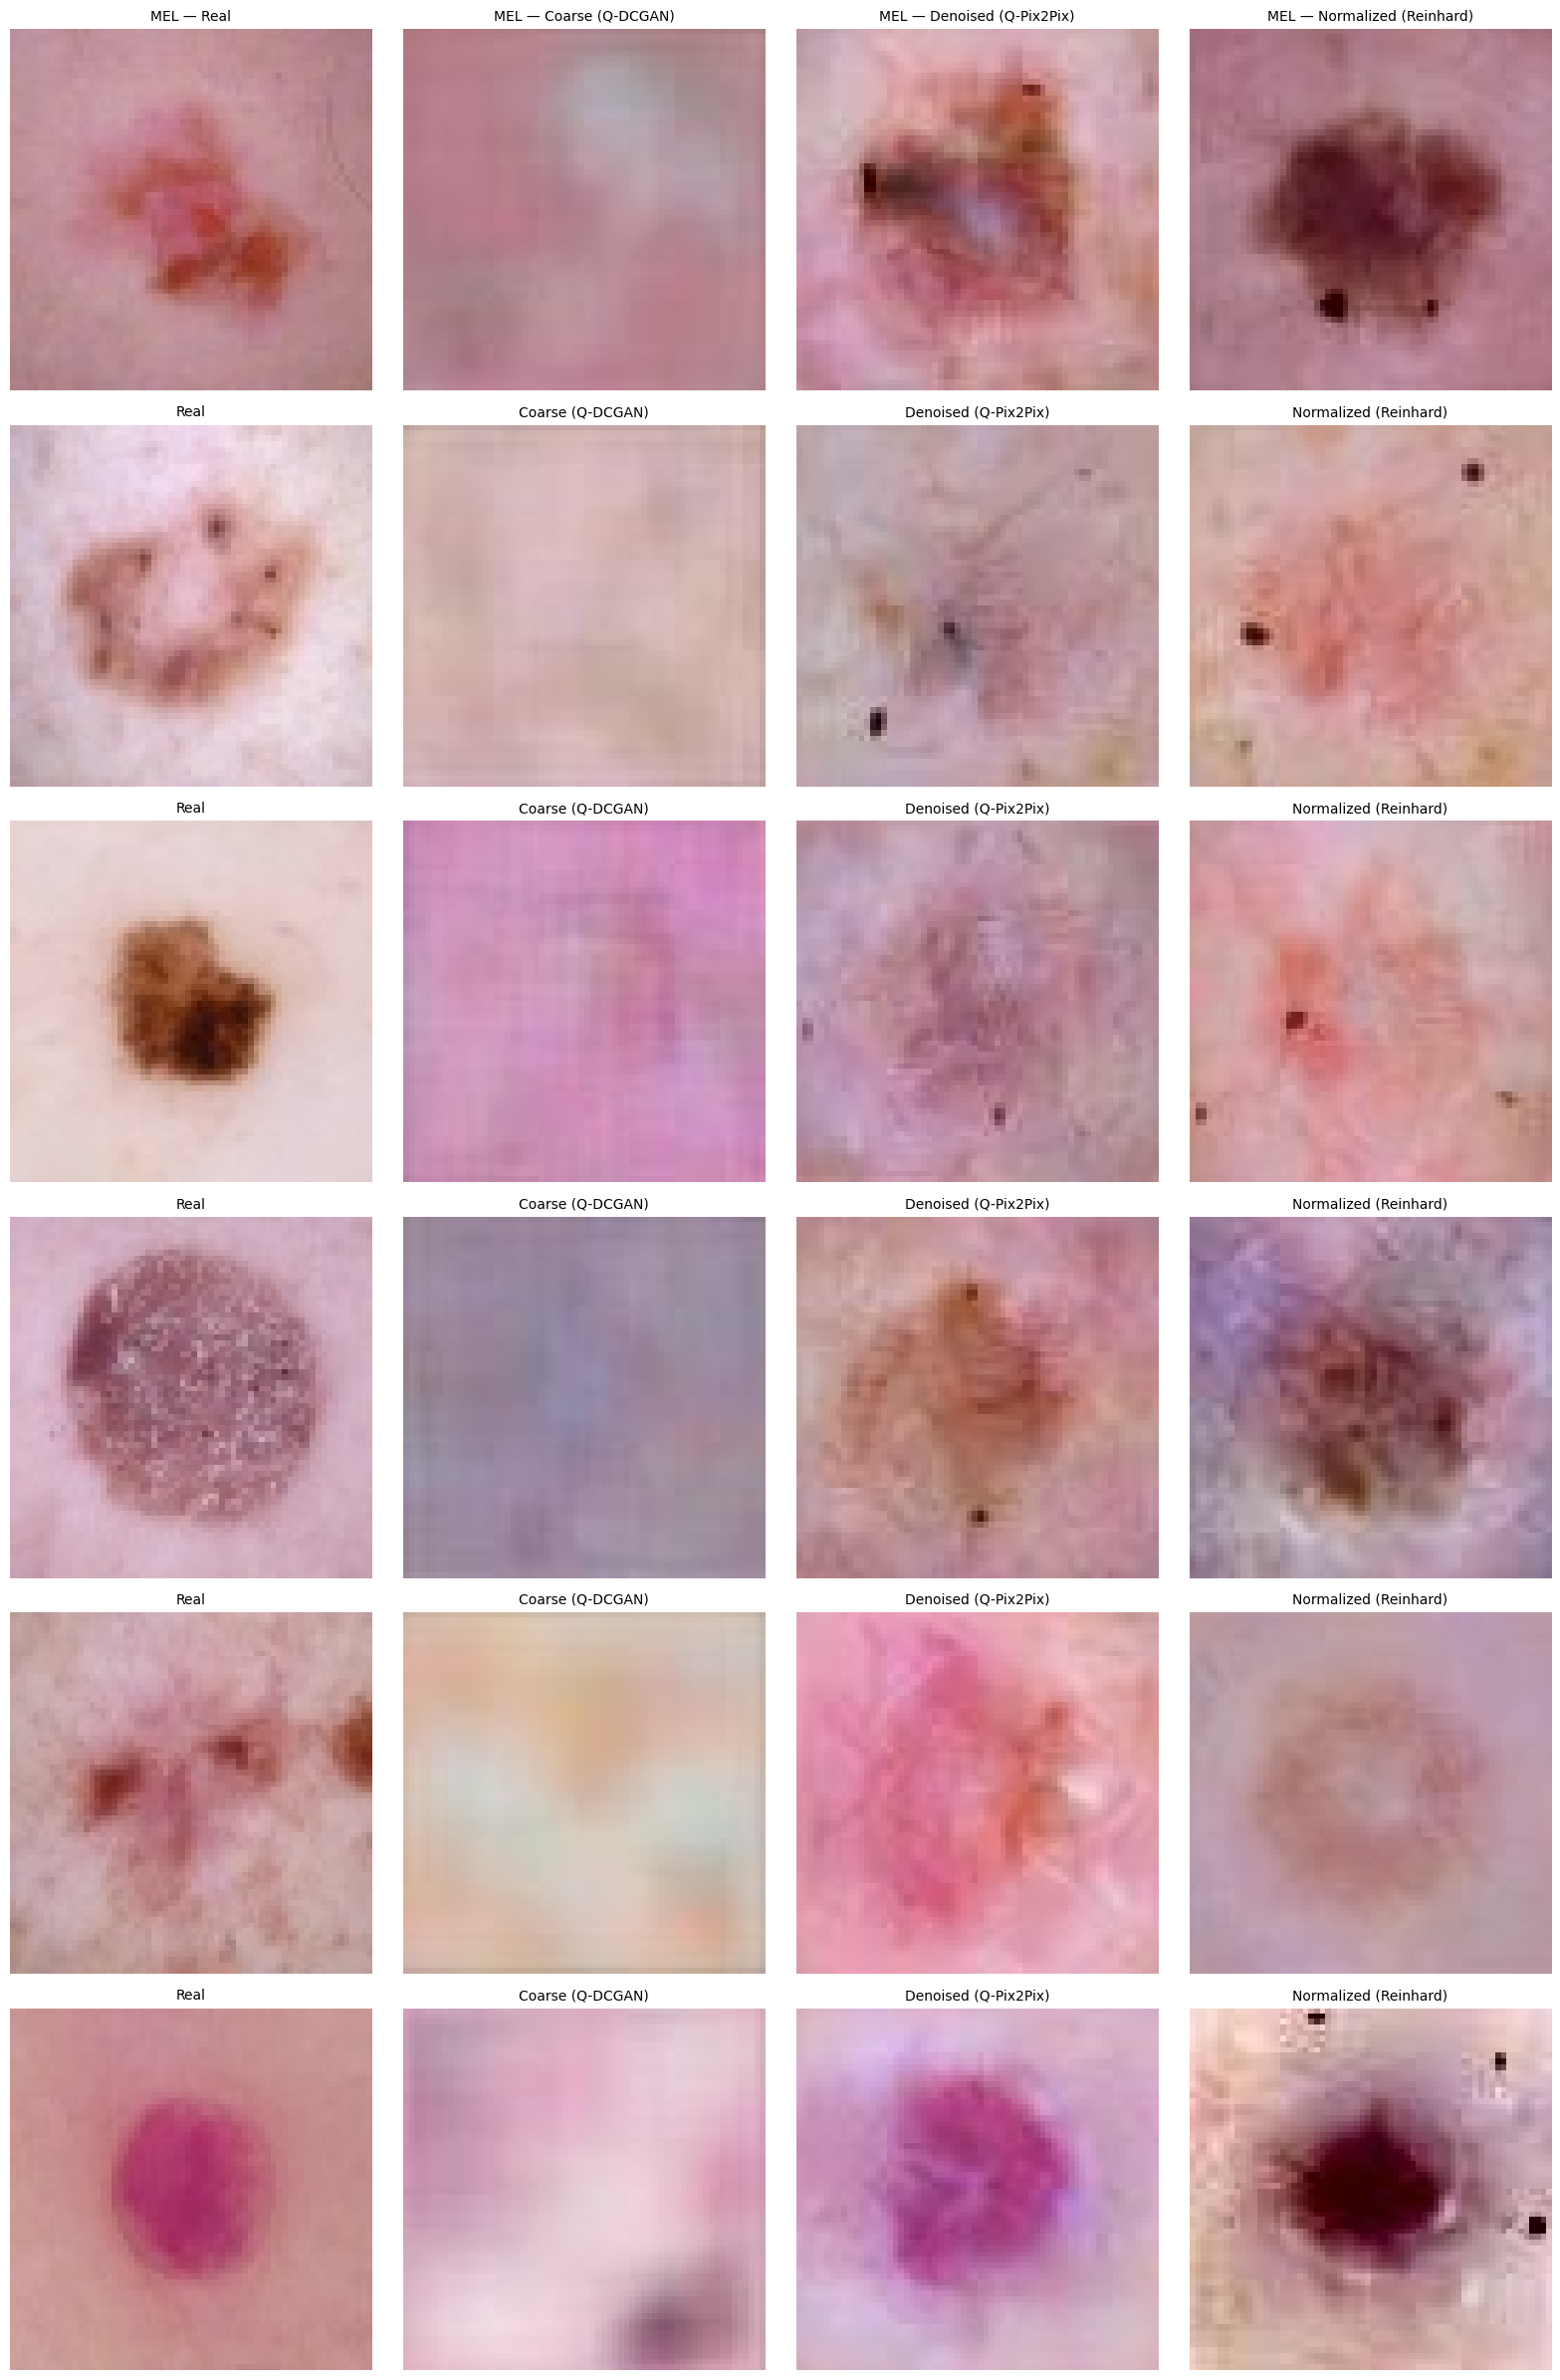

In [24]:
def show_pipeline_comparison(classes=None, n_classes_to_show: int = None):
    classes = classes or minority_classes
    if n_classes_to_show:
        classes = classes[:n_classes_to_show]

    stages = ["real", "augmented", "denoised", "normalized"]
    stage_titles = ["Real", "Coarse (Q-DCGAN)", "Denoised (Q-Pix2Pix)", "Normalized (Reinhard)"]

    fig, axes = plt.subplots(len(classes), len(stages), figsize=(4 * len(stages), 4 * len(classes)))
    if len(classes) == 1:
        axes = axes[np.newaxis, :]

    for row, cls in enumerate(classes):
        for col, (stage, title) in enumerate(zip(stages, stage_titles)):
            ax = axes[row, col]
            folder = PROCESSED_DIR / cls / stage
            paths = sorted(folder.glob("*.jpg")) if folder.exists() else []
            if paths:
                img = Image.open(random.choice(paths)).convert("RGB")
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center")
            ax.set_title(f"{cls} — {title}" if row == 0 else title, fontsize=10)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


if DATASET_FOUND and minority_classes:
    show_pipeline_comparison()
else:
    print("Nothing to visualize yet — run the dataset discovery and training cells above first.")


## Summary

| Stage | Output location |
|---|---|
| Preprocessing (mask-cropped) | `skin cancer/dataset/processed_images/{class}/real/` |
| Stage 1 (Q-DCGAN) | `skin cancer/dataset/processed_images/{class}/augmented/` |
| Stage 2 (Q-Pix2Pix) | `skin cancer/dataset/processed_images/{class}/denoised/` |
| Stage 3 (Reinhard) | `skin cancer/dataset/processed_images/{class}/normalized/` |
| Final labels | `skin cancer/final_labels_onehot.csv` |
| Model checkpoints | `skin cancer/checkpoints/qdcgan_{class}.pt`, `skin cancer/checkpoints/pix2pix.pt` |

**Checkpoints:** Stage 1/2 training cells automatically load an existing checkpoint instead of retraining, unless `FORCE_RETRAIN = True` is set.

**Masks:** if `dataset/masks/{image_id}_segmentation.png` exists for an image, preprocessing crops to the lesion's bounding box instead of an arbitrary center-crop.

**To run a full training pass:** increase `QDCGAN_EPOCHS` / `PIX2PIX_EPOCHS` to realistic values (e.g. 100–300) and run all cells top to bottom on a CUDA-enabled machine.
